In [12]:
from pytential.sympy_pytential import sympy_pytential
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from pytential.reduce import min_pytential#, pyt_minimizer
from pytential.reduce.matrix_methods import equality_qp_dual, equality_qp, reduce_qp

# Define 2 binary phases

Create two ideal mixing functions from a set of properties, and check them.

In [13]:
from sympy import log, symbols
c0a, c1a, c0b, c1b, c0, c1, Va, Vb = symbols('c0a, c1a, c0b, c1b, c0, c1, Va, Vb')

In [14]:
RT = 8.134*300
kappa = 10000
fa_sp = c0a*RT*(1+log(c0a/(c0a+c1a))) +c1a*RT*(0+log(c1a/(c0a+c1a)))+(c0a+c1a)*kappa/2*(log(Va/(c0a+c1a)))**2
fb_sp = c0b*RT*(0+log(c0b/(c0b+c1b))) +c1b*RT*(1+log(c1b/(c0b+c1b)))+(c0b+c1b)*kappa/2*(log(Vb/(c0b+c1b)))**2

In [15]:
fa = sympy_pytential(fa_sp, ['c0a', 'c1a', 'Va'])
fb = sympy_pytential(fb_sp) # The variables are automatically detected
print(fb)

x = ['Vb', 'c0b', 'c1b']

f(x) = 2440.2*c0b*log(c0b/(c0b + c1b)) + 2440.2*c1b*(log(c1b/(c0b + c1b)) + 1) + (5000*c0b + 5000*c1b)*log(Vb/(c0b + c1b))**2

f'(x)= [10000*(c0b + c1b)*log(Vb/(c0b + c1b))/Vb, 5000.0*log(Vb/(c0b + c1b))**2 - 10000.0*log(Vb/(c0b + c1b)) + 2440.2*log(c0b/(c0b + c1b)), 5000.0*log(Vb/(c0b + c1b))**2 - 10000.0*log(Vb/(c0b + c1b)) + 2440.2*log(c1b/(c0b + c1b)) + 2440.2]

f"(x)= [[10000*(c0b + c1b - (c0b + c1b)*log(Vb/(c0b + c1b)))/Vb**2, 10000*(log(Vb/(c0b + c1b)) - 1)/Vb, 10000*(log(Vb/(c0b + c1b)) - 1)/Vb], [10000*(log(Vb/(c0b + c1b)) - 1)/Vb, (-4880.4*c0b*c1b + c0b*(2440.2 - 20000*log(Vb/(c0b + c1b)))*(c0b + c1b) + c0b*(7559.8*c0b + 12440.2*c1b + 10000*(c0b + c1b)*log(Vb/(c0b + c1b))) + 2440.2*c1b*(c0b + c1b))/(c0b*(c0b + c1b)**2), 1.0*(7559.8 - 10000.0*log(Vb/(c0b + c1b)))/(c0b + c1b)], [10000*(log(Vb/(c0b + c1b)) - 1)/Vb, 1.0*(7559.8 - 10000.0*log(Vb/(c0b + c1b)))/(c0b + c1b), (-4880.4*c0b*c1b + 2440.2*c0b*(c0b + c1b) + c1b*(2440.2 - 20000*log(Vb/(c0b + c1b)))

## Plot V=1

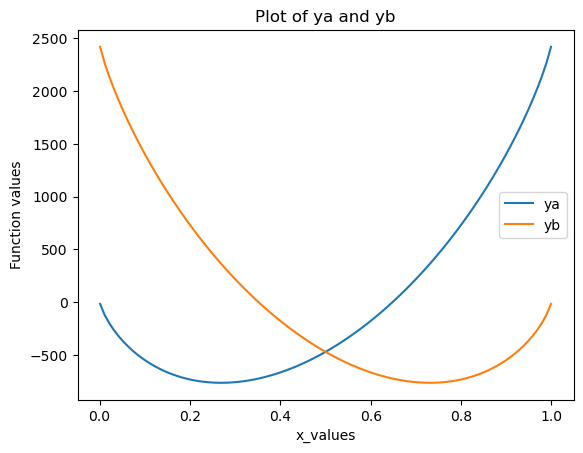

In [16]:
x_values = np.linspace(0.001, .999, 100);
ya = fa(c0a=x_values, c1a=1-x_values, Va = 1)
yb = fb(c0b = x_values, c1b = 1-x_values, Vb = 1)

plt.plot(x_values, ya, label='ya')
plt.plot(x_values, yb, label='yb')
plt.xlabel('x_values')
plt.ylabel('Function values')
plt.title('Plot of ya and yb')
plt.legend()
plt.show()

## Plot density variation

In [17]:

X, Y = np.meshgrid(x_values, x_values)
Z = fa([X, Y, 1])

fig = go.Figure()

# Add the 3D surface plot for fa
fig.add_trace(go.Surface(
    z=Z,
    x=x_values, 
    y=x_values, 
    colorscale='Viridis',
    name='fa surface',
    showlegend=True
))

# Add the line where c0a + c1a = Va
fig.add_trace(go.Scatter3d(
    x=x_values, 
    y=1-x_values, 
    z=fa(c0a=x_values, c1a=1-x_values, Va=1), 
    mode='lines', 
    name='c0a + c1a = Va', 
    line=dict(color='red', width=4),
    showlegend=True
))

# Update layout for the plot
fig.update_layout(
    title='3D Surface Plot of fa(x_values, x_values, Va=1)',
    legend=dict(title="Legend", x=0.8, y=0.9, bgcolor="rgba(255, 255, 255, 0.7)"),
    scene=dict(
        xaxis_title='c0a',
        yaxis_title='c1a',
        zaxis_title='fa values',
        aspectratio=dict(x=1, y=1, z=1)
    )
)
fig.show()

# Form a composite function

Make a function fa+fb with all the variables, and add constraints that the concentrations must sum to ca and cb

In [7]:
f = fa+fb
print(f)

x = ['Va', 'Vb', 'c0a', 'c0b', 'c1a', 'c1b']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c0b*log(c0b/(c0b + c1b)) + 2440.2*c1a*log(c1a/(c0a + c1a)) + 2440.2*c1b*(log(c1b/(c0b + c1b)) + 1) + (5000*c0a + 5000*c1a)*log(Va/(c0a + c1a))**2 + (5000*c0b + 5000*c1b)*log(Vb/(c0b + c1b))**2

f'(x)= [10000*(c0a + c1a)*log(Va/(c0a + c1a))/Va, 10000*(c0b + c1b)*log(Vb/(c0b + c1b))/Vb, 5000.0*log(Va/(c0a + c1a))**2 - 10000.0*log(Va/(c0a + c1a)) + 2440.2*log(c0a/(c0a + c1a)) + 2440.2, 5000.0*log(Vb/(c0b + c1b))**2 - 10000.0*log(Vb/(c0b + c1b)) + 2440.2*log(c0b/(c0b + c1b)), 5000.0*log(Va/(c0a + c1a))**2 - 10000.0*log(Va/(c0a + c1a)) + 2440.2*log(c1a/(c0a + c1a)), 5000.0*log(Vb/(c0b + c1b))**2 - 10000.0*log(Vb/(c0b + c1b)) + 2440.2*log(c1b/(c0b + c1b)) + 2440.2]

f"(x)= [[10000*(c0a + c1a - (c0a + c1a)*log(Va/(c0a + c1a)))/Va**2, 0, 10000*(log(Va/(c0a + c1a)) - 1)/Va, 0, 10000*(log(Va/(c0a + c1a)) - 1)/Va, 0], [0, 10000*(c0b + c1b - (c0b + c1b)*log(Vb/(c0b + c1b)))/Vb**2, 0, 10000*(log(Vb/(

In [8]:
f2 = f.add_constraints_sym([c0a+c0b-c0, c1a+c1b-c1])
print(f2)

x = ['Va', 'Vb', 'c0', 'c0a', 'c0b', 'c1', 'c1a', 'c1b']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c0b*log(c0b/(c0b + c1b)) + 2440.2*c1a*log(c1a/(c0a + c1a)) + 2440.2*c1b*(log(c1b/(c0b + c1b)) + 1) + (5000*c0a + 5000*c1a)*log(Va/(c0a + c1a))**2 + (5000*c0b + 5000*c1b)*log(Vb/(c0b + c1b))**2

f'(x)= [10000*(c0a + c1a)*log(Va/(c0a + c1a))/Va, 10000*(c0b + c1b)*log(Vb/(c0b + c1b))/Vb, 0, 5000.0*log(Va/(c0a + c1a))**2 - 10000.0*log(Va/(c0a + c1a)) + 2440.2*log(c0a/(c0a + c1a)) + 2440.2, 5000.0*log(Vb/(c0b + c1b))**2 - 10000.0*log(Vb/(c0b + c1b)) + 2440.2*log(c0b/(c0b + c1b)), 0, 5000.0*log(Va/(c0a + c1a))**2 - 10000.0*log(Va/(c0a + c1a)) + 2440.2*log(c1a/(c0a + c1a)), 5000.0*log(Vb/(c0b + c1b))**2 - 10000.0*log(Vb/(c0b + c1b)) + 2440.2*log(c1b/(c0b + c1b)) + 2440.2]

f"(x)= [[10000*(c0a + c1a - (c0a + c1a)*log(Va/(c0a + c1a)))/Va**2, 0, 0, 10000*(log(Va/(c0a + c1a)) - 1)/Va, 0, 0, 10000*(log(Va/(c0a + c1a)) - 1)/Va, 0], [0, 10000*(c0b + c1b - (c0b + c1b)*log(Vb/(c0b + c1b)))/V

In [9]:
y0 = {'Va':.5, 'Vb':.5, 'c0a':.5, 'c0b':.5, 'c1a':.5, 'c1b':.5, 'c0':0,'c1':0}
print(y0)

{'Va': 0.5, 'Vb': 0.5, 'c0a': 0.5, 'c0b': 0.5, 'c1a': 0.5, 'c1b': 0.5, 'c0': 0, 'c1': 0}


In [10]:
fq = f2.quadratic_expansion(y0)
print(fq)
print(fq.vars)
print(fq.grad(**y0))

x = ['Va', 'Vb', 'c0', 'c0a', 'c0b', 'c1', 'c1a', 'c1b']

f(x) = 0.5*Va*(67725.8872223978*Va - 33862.9436111989*c0a - 33862.9436111989*c1a) - 13862.9436111989*Va + 0.5*Vb*(67725.8872223978*Vb - 33862.9436111989*c0b - 33862.9436111989*c1b) - 13862.9436111989*Vb + 0.5*c0a*(-33862.9436111989*Va + 19371.6718055995*c0a + 14491.2718055995*c1a) + 10082.5191251881*c0a + 0.5*c0b*(-33862.9436111989*Vb + 19371.6718055995*c0b + 14491.2718055995*c1b) + 7642.31912518808*c0b + 0.5*c1a*(-33862.9436111989*Va + 14491.2718055995*c0a + 19371.6718055995*c1a) + 7642.31912518808*c1a + 0.5*c1b*(-33862.9436111989*Vb + 14491.2718055995*c0b + 19371.6718055995*c1b) + 10082.5191251881*c1b + 3861.89463917726

f'(x)= [67725.8872223978*Va - 33862.9436111989*c0a - 33862.9436111989*c1a - 13862.9436111989, 67725.8872223978*Vb - 33862.9436111989*c0b - 33862.9436111989*c1b - 13862.9436111989, 0, -33862.9436111989*Va + 19371.6718055995*c0a + 14491.2718055995*c1a + 10082.5191251881, -33862.9436111989*Vb + 19371.6718055995*c

In [11]:
fr = fq.remove_linear_constraints(vars_to_keep=['c0', 'c1', 'Va', 'Vb'], y0=y0)
print(fr)
print(fr.vars)
print(fr.grad(**y0))

A_d has condition number 1.0, rank 2, and dimensions (2, 4)
Q_tilde is symmetric.
Lagrange multiplier:  [8862.41912519 8862.41912519]


ValueError: too many values to unpack (expected 5)

In [ ]:
# Generate Va and Vb values
Va_values = np.linspace(0, 1, 100)

# Create a meshgrid for Va and x_values
Va_mesh, x_mesh = np.meshgrid(Va_values, x_values)

# Compute c0 and c1
c0_mesh = x_mesh
c1_mesh = 1 - x_mesh

# Flatten the meshgrid to pass as arguments to fr

# Compute Z values using the fr function
Z_flat = fr(c0=x_values, c1=-1-x_values, Va=Va_values, Vb=1-Va_values)

# Create the Plotly figure
fig = go.Figure()

# Add the 3D surface plot for fr
fig.add_trace(go.Surface(
    z=Z,
    x=x_values,
    y=Va_values,
    colorscale='Viridis',
    name='fr surface'
))

# Update layout for the plot
fig.update_layout(
    title='3D Surface Plot of fr',
    scene=dict(
        xaxis_title='c0',
        yaxis_title='Va',
        zaxis_title='fr values',
        aspectratio=dict(x=1, y=1, z=0.5)
    )
)

fig.show()